# CS3807 — Deep Learning Laboratory Experiment 5 : Comprehensive Study of CNN Training, Regularization, Optimization, Hyperparameter Tuning, Transfer Learning and Cross-Validation

## 0. Setup

In [1]:

# ---- 0b. Imports ----
import os, io, json, time, random, shutil, zipfile, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  # silence TensorFlow C++ backend startup messages
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"  # suppress the oneDNN startup notice too

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns

import tensorflow as tf
tf.get_logger().setLevel("ERROR")
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:

# ---- 0c. Global plotting style: Times New Roman 15, bold axes, 600 DPI, saved to outputs/figures ----
# Styling here mirrors Lab 4's approach exactly (same rcParams, seaborn whitegrid, label_style /
# title_style / legend_style dicts, format_axis_ticks / format_legend_text helpers) so both labs'
# figures look consistent. The font download is made defensive though: Lab 4's plain
# `wget ... ; addfont(...)` crashes with "Can not load face" if the download is empty/blocked/an
# HTML error page -- here we validate what actually got downloaded, try a second mirror, and fall
# back to a bundled serif font (never crashes the notebook) if both downloads fail.
FIG_DIR = "outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

import subprocess

FONT_PATH = "TimesNewRoman.ttf"
FONT_URLS = [
    "https://raw.githubusercontent.com/justrajdeep/fonts/master/Times%20New%20Roman.ttf",
    "https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf",
]

def _download_ok(url, out_path, min_bytes=50_000):
    """Download url -> out_path and sanity-check the result actually looks like a font file
    (right size, right magic bytes) rather than an empty file or an HTML error page."""
    result = subprocess.run(["wget", "-q", "-O", out_path, url])
    if result.returncode != 0 or not os.path.exists(out_path):
        return False
    if os.path.getsize(out_path) < min_bytes:
        return False
    with open(out_path, "rb") as f:
        magic = f.read(4)
    # TrueType: 00 01 00 00  |  OpenType/CFF: 'OTTO'  |  TrueType Collection: 'ttcf'
    if magic not in (b"\x00\x01\x00\x00", b"OTTO", b"ttcf"):
        return False
    return True

FONT_NAME = None
for url in FONT_URLS:
    if os.path.exists(FONT_PATH):
        os.remove(FONT_PATH)
    if _download_ok(url, FONT_PATH):
        try:
            shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)
            font_manager.fontManager.addfont(FONT_PATH)
            FONT_NAME = "Times New Roman"
            print("Using downloaded font:", FONT_NAME, "(from", url, ")")
            break
        except RuntimeError as e:
            print(f"Downloaded file from {url} failed to load as a font ({e}); trying next source.")

if FONT_NAME is None:
    # Both downloads failed (or crashed on load) -- fall back to a bundled serif font instead of
    # raising, so a flaky network connection never breaks the rest of the notebook.
    FONT_NAME = "serif"
    print("Could not fetch Times New Roman from any source -- falling back to the bundled",
          f"'{FONT_NAME}' font family (plots will still render, just not in Times New Roman).")

# ---- Global Plot Formatting (same rcParams / style as Lab 4) ----
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 600

plt.rcParams['font.family'] = FONT_NAME

plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15

plt.rcParams['legend.fontsize'] = 15

sns.set_style("whitegrid")
sns.set_context("notebook")

label_style = {
    'fontsize': 15,
    'fontweight': 'bold',
    'fontname': FONT_NAME
}

title_style = {
    'fontsize': 15,
    'fontweight': 'bold',
    'fontname': FONT_NAME
}

legend_style = {
    'family': FONT_NAME,
    'weight': 'bold',
    'size': 15
}

def format_axis_ticks(current_axis):
    for tick_label in (
        current_axis.get_xticklabels()
        + current_axis.get_yticklabels()
    ):
        tick_label.set_fontweight('bold')
        tick_label.set_fontname(FONT_NAME)

def format_legend_text(current_legend):
    if current_legend is not None:
        for legend_entry in current_legend.get_texts():
            legend_entry.set_fontweight('bold')
            legend_entry.set_fontname(FONT_NAME)
        legend_title = current_legend.get_title()
        if legend_title is not None:
            legend_title.set_fontweight('bold')
            legend_title.set_fontname(FONT_NAME)

def style_axes(ax):
    """Bold x & y axis labels + bold tick labels + bold legend text, Times New Roman 15
    throughout (or the serif fallback if Times New Roman could not be downloaded). Kept as a
    single call so every plotting cell elsewhere in the notebook (which calls style_axes(ax))
    didn't need to change -- internally it now reuses the same label_style/title_style dicts and
    format_axis_ticks/format_legend_text helpers as Lab 4."""
    ax.set_xlabel(ax.get_xlabel(), **label_style)
    ax.set_ylabel(ax.get_ylabel(), **label_style)
    if ax.get_title():
        ax.set_title(ax.get_title(), **title_style)
    format_axis_ticks(ax)
    format_legend_text(ax.get_legend())

def savefig(fig, name, fmt='eps'):
    """fmt='eps' (default) for vector plots (line/bar charts). Use fmt='png' for plots that
    embed raster content (e.g. confusion-matrix heatmaps, photo grids from imshow) -- EPS has
    no compression for embedded bitmaps, so a 600 DPI imshow figure can balloon to 100s of MB
    in EPS while the same figure is a few hundred KB as PNG. PNG plots also get a direct PDF
    saved alongside them (matplotlib's PDF backend compresses raster content properly, unlike
    EPS), so every plot ends up with a usable PDF for the LaTeX report."""
    ext = "png" if fmt == "png" else "eps"
    stem = os.path.splitext(name)[0]
    path = os.path.join(FIG_DIR, stem + "." + ext)
    fig.savefig(path, dpi=600, format=fmt, bbox_inches='tight')
    print("Saved:", path)
    if fmt == "png":
        pdf_path = os.path.join(FIG_DIR, stem + ".pdf")
        fig.savefig(pdf_path, dpi=600, format='pdf', bbox_inches='tight')
        print("Saved:", pdf_path)
    plt.show()


Using downloaded font: Times New Roman (from https://raw.githubusercontent.com/justrajdeep/fonts/master/Times%20New%20Roman.ttf )


In [3]:

# ---- 0d. Dataset: load Oxford-IIIT Pet directly via tensorflow_datasets (no Kaggle "Add Input" needed) ----
# Needs Kaggle Settings -> Internet: On, since tfds downloads + caches the dataset on first run.
import tensorflow_datasets as tfds

TFDS_DATA_DIR = "/kaggle/working/tensorflow_datasets"

(ds_train_raw, ds_test_raw), tfds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    data_dir=TFDS_DATA_DIR,
)

CLASS_NAMES = tfds_info.features["label"].names
NUM_CLASSES = len(CLASS_NAMES)
print("Number of breeds (classes):", NUM_CLASSES)

IMG_SIZE = (224, 224)

def _resize_uint8(img, label):
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.uint8)
    return img, label

# tfds's own train/test split (roughly 50/50) doesn't match the lab manual's 70/15/15 requirement,
# and doesn't give us a plain row index to K-Fold over later -- so pull every image into memory
# once here (resized to 224x224, uint8, ~1.1GB total for ~7.3k images) and build our own stratified
# 70/15/15 split and K-Fold splits from that, the same way the rest of the notebook already expects.
full_ds = ds_train_raw.concatenate(ds_test_raw).map(_resize_uint8, num_parallel_calls=tf.data.AUTOTUNE)

images_list, labels_list = [], []
for img, label in tfds.as_numpy(full_ds):
    images_list.append(img)
    labels_list.append(label)

ALL_IMAGES = np.stack(images_list, axis=0)   # (N, 224, 224, 3) uint8
ALL_LABELS = np.array(labels_list, dtype=np.int64)
del images_list, labels_list
print("Total images loaded into memory:", ALL_IMAGES.shape, "| labels:", ALL_LABELS.shape)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

I0000 00:00:1788082379.940290      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788082379.943629      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Shuffling /kaggle/working/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-train.tf…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /kaggle/working/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-test.tfr…

Dataset oxford_iiit_pet downloaded and prepared to /kaggle/working/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Number of breeds (classes): 37
Total images loaded into memory: (7349, 224, 224, 3) | labels: (7349,)


In [4]:

# ---- 0f. Row-index/label dataframe & train/val/test split ----
# Every row just points at a row of ALL_IMAGES/ALL_LABELS -- this keeps the rest of the notebook
# (K-Fold splitting via .iloc, etc.) working exactly as it did with the old filepath-based dataframe.
df = pd.DataFrame({"idx": np.arange(len(ALL_LABELS)), "label": ALL_LABELS})
print("Total images:", len(df))
print("Number of breeds (classes):", df['label'].nunique())

# Train / Val / Test split: 70 / 15 / 15, stratified on breed. Test set held out from ALL tuning.
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
train_df.to_csv("outputs/train_split.csv", index=False)
val_df.to_csv("outputs/val_split.csv", index=False)
test_df.to_csv("outputs/test_split.csv", index=False)


Total images: 7349
Number of breeds (classes): 37
Train: 5144 Val: 1102 Test: 1103


In [5]:

# ---- 0g. tf.data pipeline builder (reusable across all experiments) ----
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE_DEFAULT = 32

def augment_and_normalize(img, label, augment=False):
    """Cheap, per-epoch-varying ops -- MobileNetV2 preprocessing is applied last."""
    img = tf.cast(img, tf.float32)
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.1)
    img = preprocess_input(img)
    return img, label

def make_dataset(dframe, batch_size=BATCH_SIZE_DEFAULT, shuffle=False, augment=False, cache=True, cache_path=""):
    """Builds a batched tf.data.Dataset for the rows of `dframe` (indexing straight into the
    in-memory ALL_IMAGES/ALL_LABELS arrays loaded via tfds -- no file I/O left to do).
    cache_path is accepted but unused: it's kept purely so every existing call site elsewhere in
    the notebook (which still passes a disk cache path) keeps working unmodified. cache=True now
    just does a cheap in-memory tf.data .cache() instead of a disk-backed one."""
    idxs = dframe['idx'].values
    imgs = ALL_IMAGES[idxs]
    labels = tf.one_hot(dframe['label'].values, NUM_CLASSES).numpy()
    ds = tf.data.Dataset.from_tensor_slices((imgs, labels))
    if cache:
        ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dframe), seed=SEED)
    ds = ds.map(lambda img, l: augment_and_normalize(img, l, augment=augment), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True, augment=True, cache=True, cache_path="/kaggle/working/cache/train")
val_ds   = make_dataset(val_df, cache=True, cache_path="/kaggle/working/cache/val")
test_ds  = make_dataset(test_df, cache=True, cache_path="/kaggle/working/cache/test")

print("Datasets built (in-memory, via tensorflow_datasets -- no disk caching needed anymore).")
print("Steps/epoch (train):", len(train_df)//BATCH_SIZE_DEFAULT)


Datasets built (in-memory, via tensorflow_datasets -- no disk caching needed anymore).
Steps/epoch (train): 160


In [6]:

# ---- 0h. Model builder helper: MobileNetV2 base + custom classifier head ----
def build_mobilenetv2_model(num_classes=NUM_CLASSES,
                             trainable_base=False,
                             unfreeze_from=None,
                             dropout_rate=0.5,
                             use_batchnorm=True,
                             l2_reg=0.0,
                             kernel_initializer="glorot_uniform",
                             weights="imagenet"):
    base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights=weights)
    base_model.trainable = trainable_base
    if trainable_base and unfreeze_from is not None:
        for layer in base_model.layers[:unfreeze_from]:
            layer.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=trainable_base)
    x = layers.GlobalAveragePooling2D()(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu',
                      kernel_initializer=kernel_initializer,
                      kernel_regularizer=regularizers.l2(l2_reg) if l2_reg > 0 else None)(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax',
                            kernel_initializer=kernel_initializer)(x)
    model = keras.Model(inputs, outputs)
    return model, base_model

def compile_model(model, optimizer, lr=1e-3):
    opt_map = {
        "sgd": optimizers.SGD(learning_rate=lr),
        "momentum": optimizers.SGD(learning_rate=lr, momentum=0.9),
        "rmsprop": optimizers.RMSprop(learning_rate=lr),
        "adam": optimizers.Adam(learning_rate=lr),
    }
    opt = opt_map[optimizer] if isinstance(optimizer, str) else optimizer
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def reset_keras(*objs):
    """Proper cleanup between training runs. clear_session() alone does not release everything --
    Python-level references to old model/base objects (and the C++ tensors they wrap) can persist
    until garbage collected, and this compounds badly across many loop iterations (Sections 1,2,4,5,
    7,10 each train several models back-to-back). This deletes the passed-in objects, clears the
    Keras session/graph, and forces a garbage-collection pass so memory is actually reclaimed before
    the next model is built."""
    import gc
    for o in objs:
        try:
            del o
        except Exception:
            pass
    keras.backend.clear_session()
    gc.collect()

def clear_disk_cache(path="/kaggle/working/cache"):
    """Remove disk-cached dataset tensors once a section that relies on them is finished, so cache
    files don't sit around consuming disk space unnecessarily across a long notebook run."""
    shutil.rmtree(path, ignore_errors=True)
    print(f"Cleared disk cache at {path}")

print("Model builder and cleanup helpers ready.")


Model builder and cleanup helpers ready.


## 1. Weight Initialization


=== Training with Zero initialization ===
Cleared disk cache at /kaggle/working/cache
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8


I0000 00:00:1788082422.272033     160 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


161/161 ━━━━━━━━━━━━━━━━━━━━ 50s 194ms/step - accuracy: 0.0229 - loss: 3.6114 - val_accuracy: 0.0272 - val_loss: 3.6109
Epoch 2/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.0206 - loss: 3.6114 - val_accuracy: 0.0272 - val_loss: 3.6109
Epoch 3/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.0206 - loss: 3.6113 - val_accuracy: 0.0272 - val_loss: 3.6108
Epoch 4/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.0237 - loss: 3.6113 - val_accuracy: 0.0272 - val_loss: 3.6108
Epoch 5/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.0220 - loss: 3.6112 - val_accuracy: 0.0272 - val_loss: 3.6108
Epoch 6/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.0204 - loss: 3.6113 - val_accuracy: 0.0272 - val_loss: 3.6108
Epoch 7/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.0206 - loss: 3.6112 - val_accuracy: 0.0272 - val_loss: 3.6108
Epoch 8/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.0208 - loss: 3.6112 - val_accuracy: 0.0272 - v

Saved: outputs/figures/plot01_training_loss_vs_epoch_initialization.eps


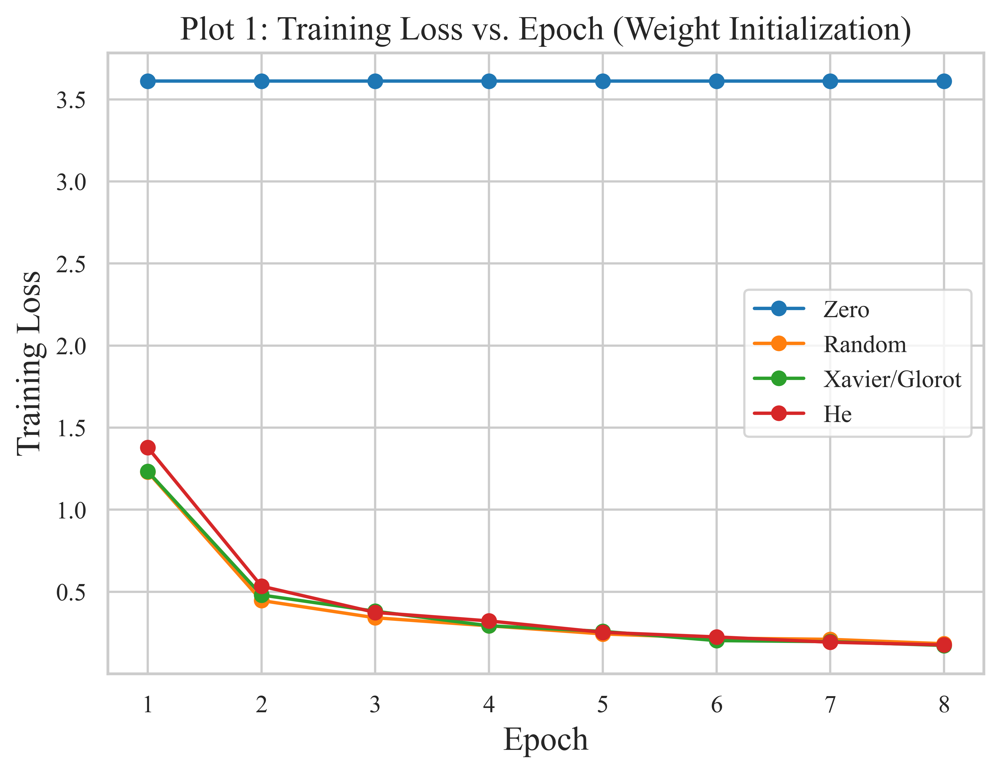

Saved: outputs/figures/plot02_val_accuracy_vs_epoch_initialization.eps


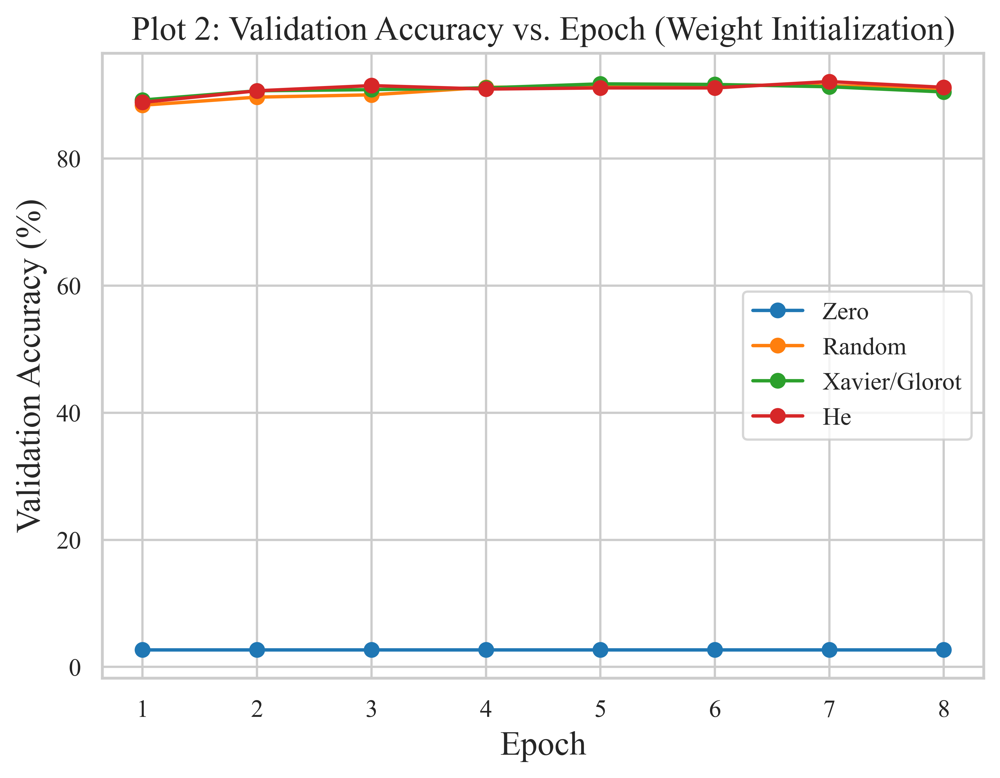

In [7]:

# Compare Zero, Random(Normal), Xavier/Glorot, He initialization.
# Only the newly-added classifier head's initializer is varied (base is pretrained ImageNet weights, frozen).
EPOCHS_INIT = 8
init_schemes = {
    "Zero": keras.initializers.Zeros(),
    "Random": keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=SEED),
    "Xavier/Glorot": keras.initializers.GlorotUniform(seed=SEED),
    "He": keras.initializers.HeNormal(seed=SEED),
}

init_histories = {}
for name, init in init_schemes.items():
    print(f"\n=== Training with {name} initialization ===")
    # Clear and rebuild the disk cache fresh for every single iteration. Reusing one shared cache
    # across all 4 runs means the very first .fit() call must finish writing the whole cache file --
    # if that run is interrupted or OOMs partway through, the cache file is left in a corrupt/partial
    # state and every subsequent run reading from it can crash too. Rebuilding per-iteration keeps
    # each run isolated and self-contained.
    clear_disk_cache()
    t_ds = make_dataset(train_df, shuffle=True, augment=True, cache=True,
                         cache_path="/kaggle/working/cache/train_init")
    v_ds = make_dataset(val_df, cache=True, cache_path="/kaggle/working/cache/val_init")

    model, base = build_mobilenetv2_model(trainable_base=False, dropout_rate=0.5,
                                           use_batchnorm=True, kernel_initializer=init)
    compile_model(model, "adam", lr=1e-3)
    hist = model.fit(t_ds, validation_data=v_ds, epochs=EPOCHS_INIT, verbose=1)
    init_histories[name] = hist.history
    reset_keras(model, base, hist, t_ds, v_ds)
    clear_disk_cache()  # cache no longer needed once this iteration's training is done

# Plot 1: Training Loss vs Epoch
fig, ax = plt.subplots(figsize=(7,5))
for name, h in init_histories.items():
    ax.plot(range(1, len(h['loss'])+1), h['loss'], marker='o', label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Training Loss"); ax.set_title("Plot 1: Training Loss vs. Epoch (Weight Initialization)")
ax.legend()
style_axes(ax)
savefig(fig, "plot01_training_loss_vs_epoch_initialization.eps")

# Plot 2: Validation Accuracy vs Epoch
fig, ax = plt.subplots(figsize=(7,5))
for name, h in init_histories.items():
    ax.plot(range(1, len(h['val_accuracy'])+1), [v*100 for v in h['val_accuracy']], marker='o', label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)"); ax.set_title("Plot 2: Validation Accuracy vs. Epoch (Weight Initialization)")
ax.legend()
style_axes(ax)
savefig(fig, "plot02_val_accuracy_vs_epoch_initialization.eps")


## 2. Regularization and Overfitting


=== Training with No Regularization ===
Cleared disk cache at /kaggle/working/cache
Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 25s 104ms/step - accuracy: 0.7934 - loss: 0.7590 - val_accuracy: 0.8802 - val_loss: 0.3599
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9290 - loss: 0.2144 - val_accuracy: 0.9002 - val_loss: 0.2922
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9584 - loss: 0.1252 - val_accuracy: 0.9011 - val_loss: 0.3253
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9751 - loss: 0.0865 - val_accuracy: 0.8966 - val_loss: 0.3155
Epoch 5/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9835 - loss: 0.0607 - val_accuracy: 0.9147 - val_loss: 0.2635
Epoch 6/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9893 - loss: 0.0439 - val_accuracy: 0.9002 - val_loss: 0.2896
Epoch 7/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9907 - loss: 0.0359 - val_accuracy: 0.9129 - val_loss: 0.2814
Epoch 8/10

Saved: outputs/figures/plot03_train_val_accuracy_vs_epoch_regularization.eps


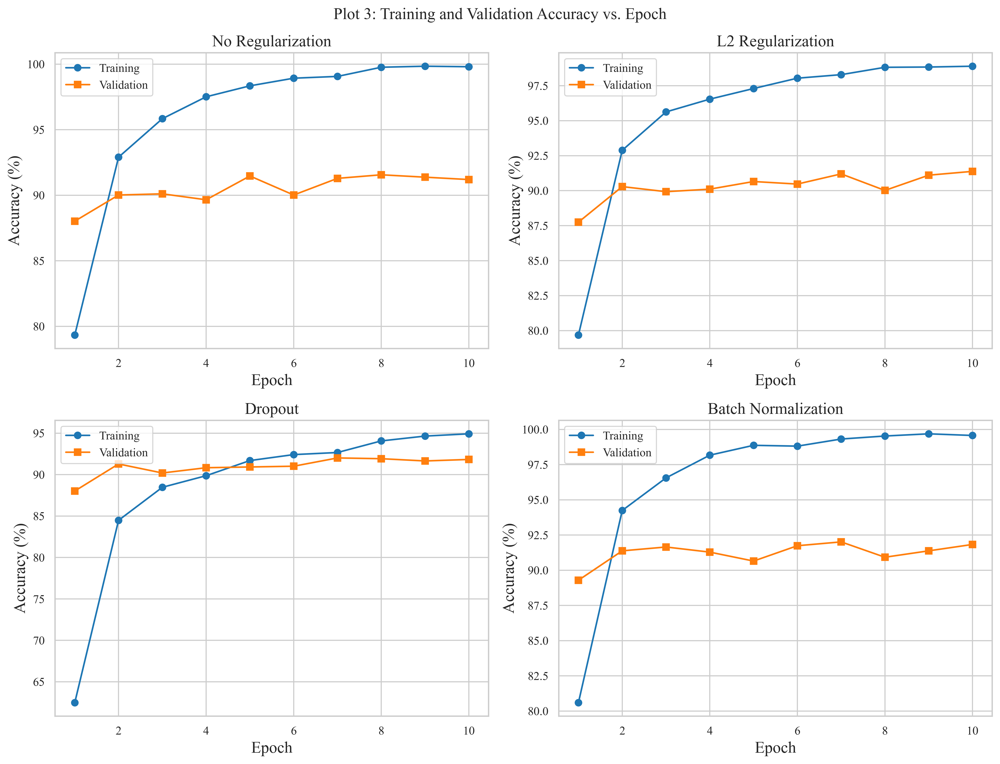

Saved: outputs/figures/plot04_train_val_loss_vs_epoch_regularization.eps


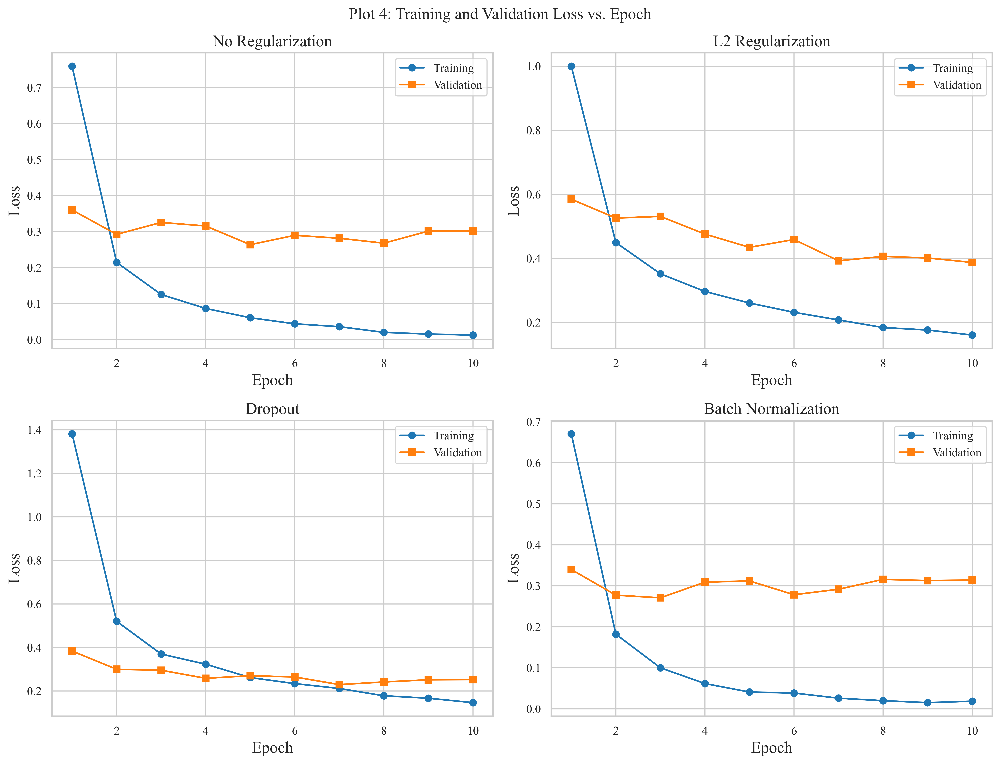

In [8]:

EPOCHS_REG = 10
reg_configs = {
    "No Regularization": dict(dropout_rate=0.0, use_batchnorm=False, l2_reg=0.0),
    "L2 Regularization":  dict(dropout_rate=0.0, use_batchnorm=False, l2_reg=1e-3),
    "Dropout":            dict(dropout_rate=0.5, use_batchnorm=False, l2_reg=0.0),
    "Batch Normalization":dict(dropout_rate=0.0, use_batchnorm=True,  l2_reg=0.0),
}

reg_histories = {}
for name, cfg in reg_configs.items():
    print(f"\n=== Training with {name} ===")
    clear_disk_cache()
    t_ds = make_dataset(train_df, shuffle=True, augment=True, cache=True,
                         cache_path="/kaggle/working/cache/train_reg")
    v_ds = make_dataset(val_df, cache=True, cache_path="/kaggle/working/cache/val_reg")

    model, base = build_mobilenetv2_model(trainable_base=False, **cfg)
    compile_model(model, "adam", lr=1e-3)
    hist = model.fit(t_ds, validation_data=v_ds, epochs=EPOCHS_REG, verbose=1)
    reg_histories[name] = hist.history
    reset_keras(model, base, hist, t_ds, v_ds)
    clear_disk_cache()

# Plot 3: Training & Validation Accuracy vs Epoch (all configs, one subplot each)
fig, axes = plt.subplots(2, 2, figsize=(13,10))
for ax, (name, h) in zip(axes.flat, reg_histories.items()):
    epochs_r = range(1, len(h['accuracy'])+1)
    ax.plot(epochs_r, [v*100 for v in h['accuracy']], marker='o', label='Training')
    ax.plot(epochs_r, [v*100 for v in h['val_accuracy']], marker='s', label='Validation')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)"); ax.set_title(name)
    ax.legend()
    style_axes(ax)
fig.suptitle("Plot 3: Training and Validation Accuracy vs. Epoch", fontweight='bold', fontsize=15, fontname=FONT_NAME)
fig.tight_layout()
savefig(fig, "plot03_train_val_accuracy_vs_epoch_regularization.eps")

# Plot 4: Training & Validation Loss vs Epoch
fig, axes = plt.subplots(2, 2, figsize=(13,10))
for ax, (name, h) in zip(axes.flat, reg_histories.items()):
    epochs_r = range(1, len(h['loss'])+1)
    ax.plot(epochs_r, h['loss'], marker='o', label='Training')
    ax.plot(epochs_r, h['val_loss'], marker='s', label='Validation')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title(name)
    ax.legend()
    style_axes(ax)
fig.suptitle("Plot 4: Training and Validation Loss vs. Epoch", fontweight='bold', fontsize=15, fontname=FONT_NAME)
fig.tight_layout()
savefig(fig, "plot04_train_val_loss_vs_epoch_regularization.eps")


## 3. Batch Normalization

Cleared disk cache at /kaggle/working/cache
Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - accuracy: 0.6633 - loss: 1.2413 - val_accuracy: 0.8820 - val_loss: 0.3832
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8604 - loss: 0.4632 - val_accuracy: 0.9065 - val_loss: 0.2887
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8847 - loss: 0.3623 - val_accuracy: 0.9120 - val_loss: 0.2924
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9020 - loss: 0.3008 - val_accuracy: 0.9065 - val_loss: 0.2875
Epoch 5/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9156 - loss: 0.2397 - val_accuracy: 0.9165 - val_loss: 0.2761
Epoch 6/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9296 - loss: 0.2052 - val_accuracy: 0.9211 - val_loss: 0.2794
Epoch 7/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9423 - loss: 0.1877 - val_accuracy: 0.9138 - val_loss: 0.2780
Epoch 8/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/ste

Cleared disk cache at /kaggle/working/cache
Saved: outputs/figures/plot05_with_vs_without_bn.eps


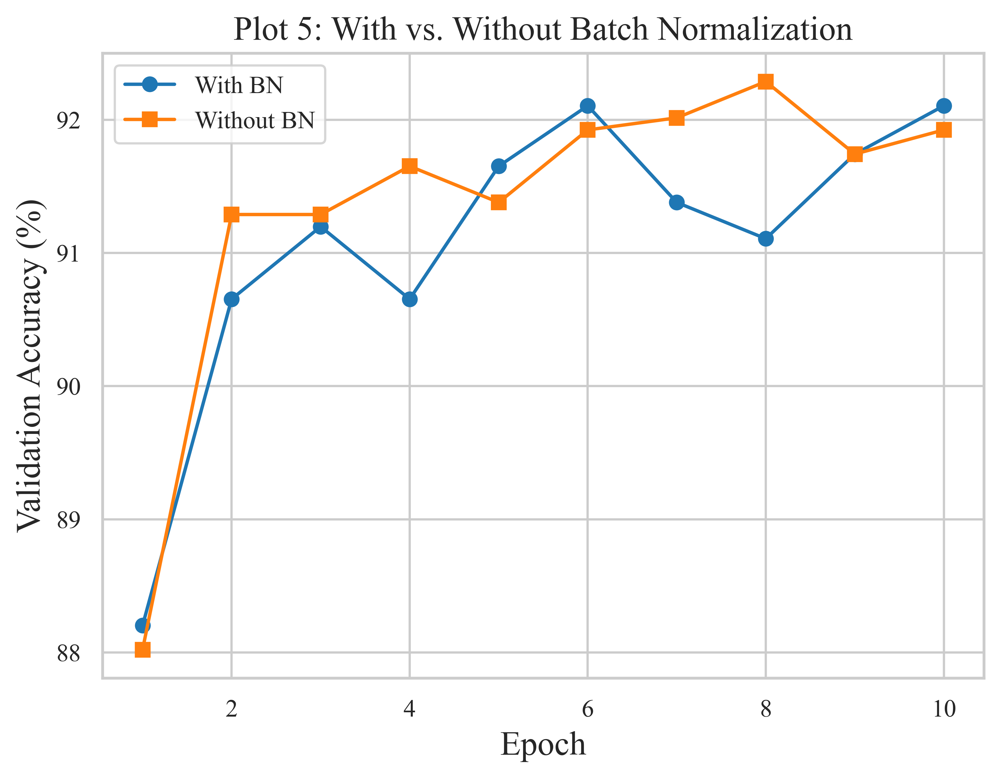

In [9]:

# With vs Without Batch Normalization — model comparison
EPOCHS_BN = 10

clear_disk_cache()
t_ds = make_dataset(train_df, shuffle=True, augment=True, cache=True,
                     cache_path="/kaggle/working/cache/train_bn")
v_ds = make_dataset(val_df, cache=True, cache_path="/kaggle/working/cache/val_bn")

model_bn, base_bn = build_mobilenetv2_model(trainable_base=False, dropout_rate=0.5, use_batchnorm=True)
compile_model(model_bn, "adam", lr=1e-3)
hist_bn = model_bn.fit(t_ds, validation_data=v_ds, epochs=EPOCHS_BN, verbose=1)
hist_bn = hist_bn.history  # keep only the plain dict; release the model/callback object
reset_keras(model_bn, base_bn)
clear_disk_cache()

t_ds = make_dataset(train_df, shuffle=True, augment=True, cache=True,
                     cache_path="/kaggle/working/cache/train_nobn")
v_ds = make_dataset(val_df, cache=True, cache_path="/kaggle/working/cache/val_nobn")

model_nobn, base_nobn = build_mobilenetv2_model(trainable_base=False, dropout_rate=0.5, use_batchnorm=False)
compile_model(model_nobn, "adam", lr=1e-3)
hist_nobn = model_nobn.fit(t_ds, validation_data=v_ds, epochs=EPOCHS_BN, verbose=1)
hist_nobn = hist_nobn.history
reset_keras(model_nobn, base_nobn, t_ds, v_ds)
clear_disk_cache()

# Plot 5: With vs Without BN
fig, ax = plt.subplots(figsize=(7,5))
ep = range(1, EPOCHS_BN+1)
ax.plot(ep, [v*100 for v in hist_bn['val_accuracy']], marker='o', label='With BN')
ax.plot(ep, [v*100 for v in hist_nobn['val_accuracy']], marker='s', label='Without BN')
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)"); ax.set_title("Plot 5: With vs. Without Batch Normalization")
ax.legend()
style_axes(ax)
savefig(fig, "plot05_with_vs_without_bn.eps")


## 4. Optimization Algorithms


=== Training with optimizer: SGD ===
Cleared disk cache at /kaggle/working/cache
Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 26s 109ms/step - accuracy: 0.0595 - loss: 4.3198 - val_accuracy: 0.1597 - val_loss: 3.2093
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.1394 - loss: 3.4330 - val_accuracy: 0.3566 - val_loss: 2.5257
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.2463 - loss: 2.8645 - val_accuracy: 0.5327 - val_loss: 1.9883
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.3402 - loss: 2.4242 - val_accuracy: 0.6379 - val_loss: 1.6093
Epoch 5/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.4201 - loss: 2.0956 - val_accuracy: 0.7178 - val_loss: 1.3389
Epoch 6/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.4864 - loss: 1.8670 - val_accuracy: 0.7523 - val_loss: 1.1440
Epoch 7/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.5311 - loss: 1.6552 - val_accuracy: 0.7731 - val_loss: 0.9970
Epoch 8/10
16

Cleared disk cache at /kaggle/working/cache
  Optimizer  Final Loss  Best Val. Accuracy  Epoch to Converge  Time (s)
0       SGD      1.2980               81.31                 10      74.6
1  Momentum      0.3619               91.38                  5      74.9
2   RMSProp      0.1765               92.38                  7      74.7
3      Adam      0.1379               91.74                  9      75.0
Saved: outputs/figures/plot06_training_loss_vs_epoch_optimizers.eps


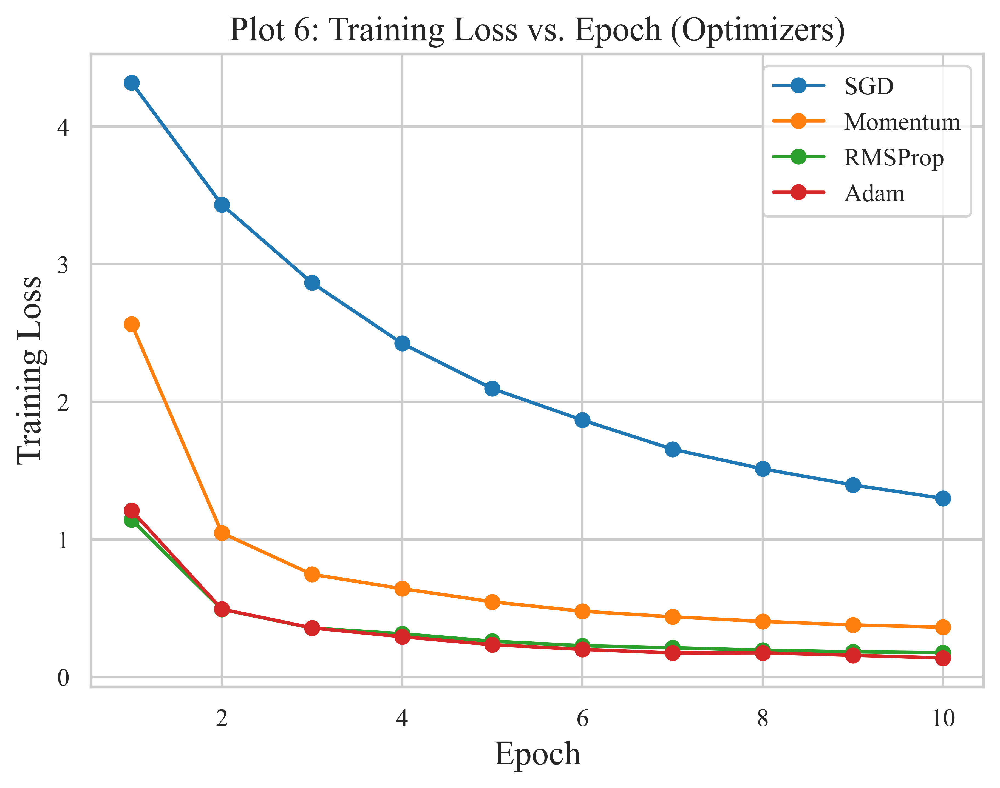

Saved: outputs/figures/plot07_val_accuracy_vs_epoch_optimizers.eps


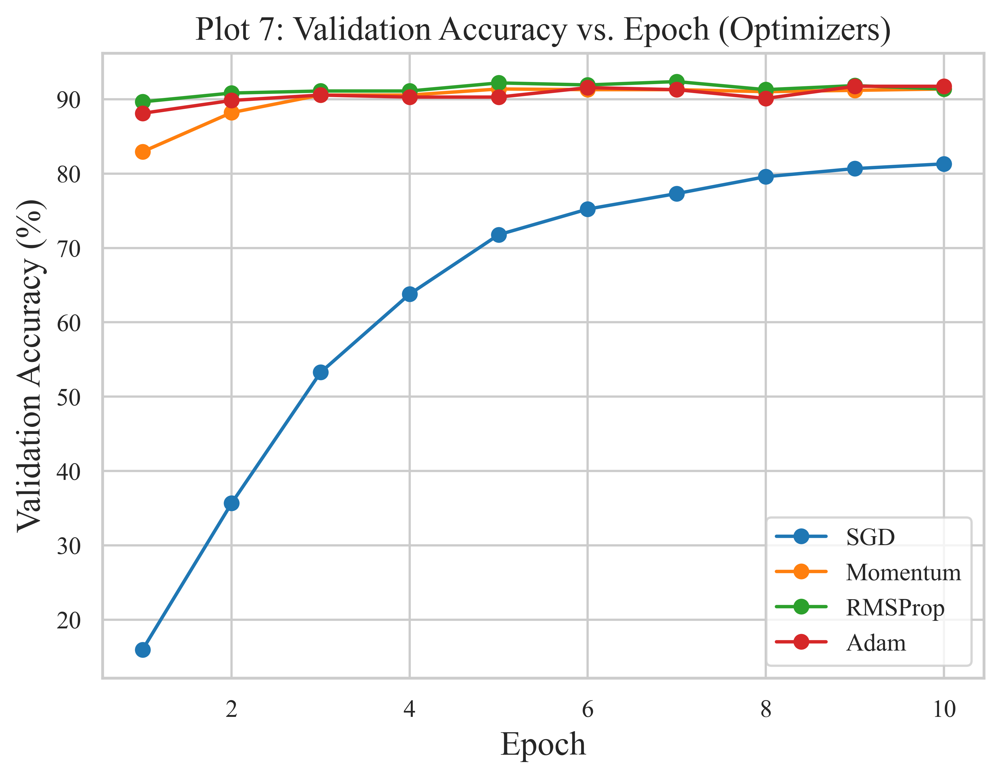

Cleared disk cache at /kaggle/working/cache


In [10]:

EPOCHS_OPT = 10
optimizer_names = ["sgd", "momentum", "rmsprop", "adam"]
opt_display = {"sgd": "SGD", "momentum": "Momentum", "rmsprop": "RMSProp", "adam": "Adam"}

opt_histories = {}
opt_summary_rows = []
for opt_name in optimizer_names:
    print(f"\n=== Training with optimizer: {opt_display[opt_name]} ===")
    clear_disk_cache()
    t_ds = make_dataset(train_df, shuffle=True, augment=True, cache=True,
                         cache_path="/kaggle/working/cache/train_opt")
    v_ds = make_dataset(val_df, cache=True, cache_path="/kaggle/working/cache/val_opt")

    model, base = build_mobilenetv2_model(trainable_base=False, dropout_rate=0.5, use_batchnorm=True)
    compile_model(model, opt_name, lr=1e-3)
    t0 = time.time()
    hist = model.fit(t_ds, validation_data=v_ds, epochs=EPOCHS_OPT, verbose=1)
    elapsed = time.time() - t0
    opt_histories[opt_display[opt_name]] = hist.history

    best_val_acc = max(hist.history['val_accuracy'])
    epoch_to_converge = int(np.argmax(hist.history['val_accuracy'])) + 1
    final_loss = hist.history['loss'][-1]
    opt_summary_rows.append({
        "Optimizer": opt_display[opt_name],
        "Final Loss": round(final_loss, 4),
        "Best Val. Accuracy": round(best_val_acc*100, 2),
        "Epoch to Converge": epoch_to_converge,
        "Time (s)": round(elapsed, 1)
    })
    reset_keras(model, base, hist, t_ds, v_ds)
    clear_disk_cache()

optimizer_summary_df = pd.DataFrame(opt_summary_rows)
optimizer_summary_df.to_csv("outputs/optimizer_summary.csv", index=False)
print(optimizer_summary_df)

# Plot 6: Training Loss vs Epoch (optimizers)
fig, ax = plt.subplots(figsize=(7,5))
for name, h in opt_histories.items():
    ax.plot(range(1, len(h['loss'])+1), h['loss'], marker='o', label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Training Loss"); ax.set_title("Plot 6: Training Loss vs. Epoch (Optimizers)")
ax.legend()
style_axes(ax)
savefig(fig, "plot06_training_loss_vs_epoch_optimizers.eps")

# Plot 7: Validation Accuracy vs Epoch (optimizers)
fig, ax = plt.subplots(figsize=(7,5))
for name, h in opt_histories.items():
    ax.plot(range(1, len(h['val_accuracy'])+1), [v*100 for v in h['val_accuracy']], marker='o', label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)"); ax.set_title("Plot 7: Validation Accuracy vs. Epoch (Optimizers)")
ax.legend()
style_axes(ax)
savefig(fig, "plot07_val_accuracy_vs_epoch_optimizers.eps")

# Sections 1-4 are done reusing the cached train_ds/val_ds at this point (Section 5's sweep below
# builds its own uncached datasets per hyperparameter value, and Section 6 will rebuild a fresh
# cache once it starts). Clear the disk cache now to free up disk space before moving on.
clear_disk_cache()


## 5. CNN Hyperparameter Tuning

Training LR=0.001
  Best Val Acc: 92.47%
Training LR=0.0001
  Best Val Acc: 90.20%
Training Batch Size=16
  Best Val Acc: 91.02%
Training Batch Size=32
  Best Val Acc: 91.47%
Training Batch Size=64
  Best Val Acc: 91.38%
Training Dropout=0.0
  Best Val Acc: 91.38%
Training Dropout=0.25
  Best Val Acc: 91.56%
Training Dropout=0.5
  Best Val Acc: 91.83%
Saved: outputs/figures/plot08_lr_vs_val_accuracy.eps


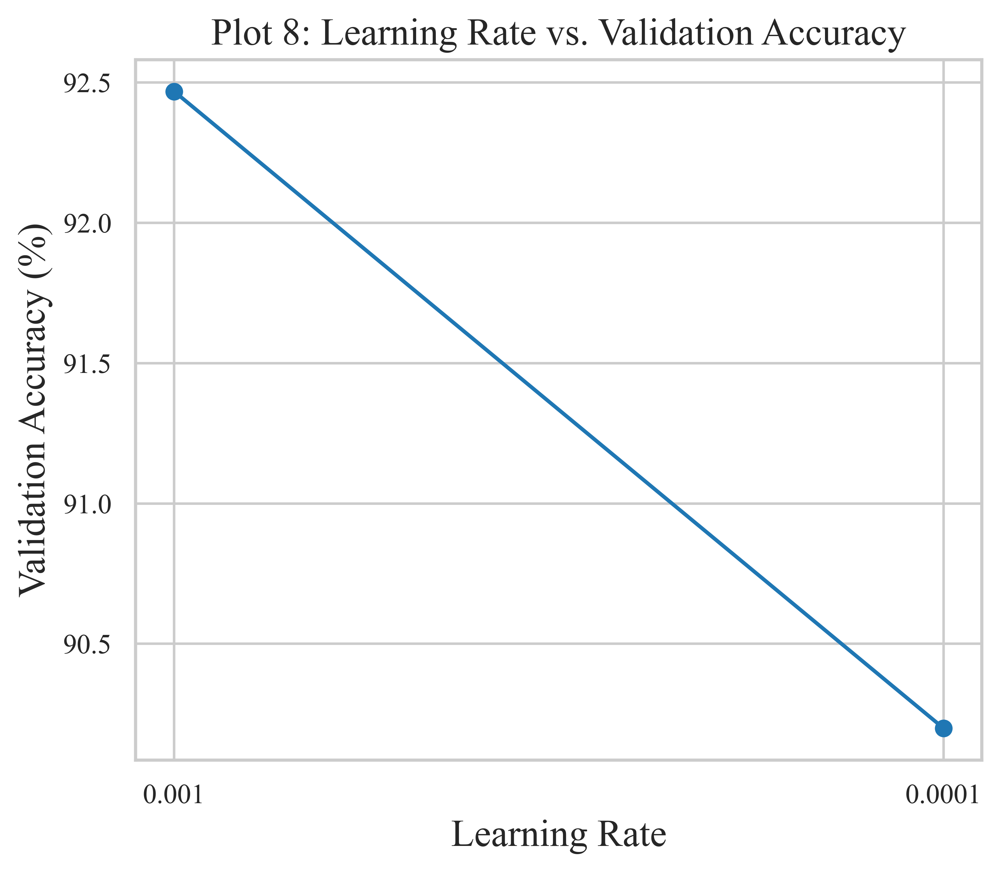

Saved: outputs/figures/plot09_batchsize_vs_val_accuracy.eps


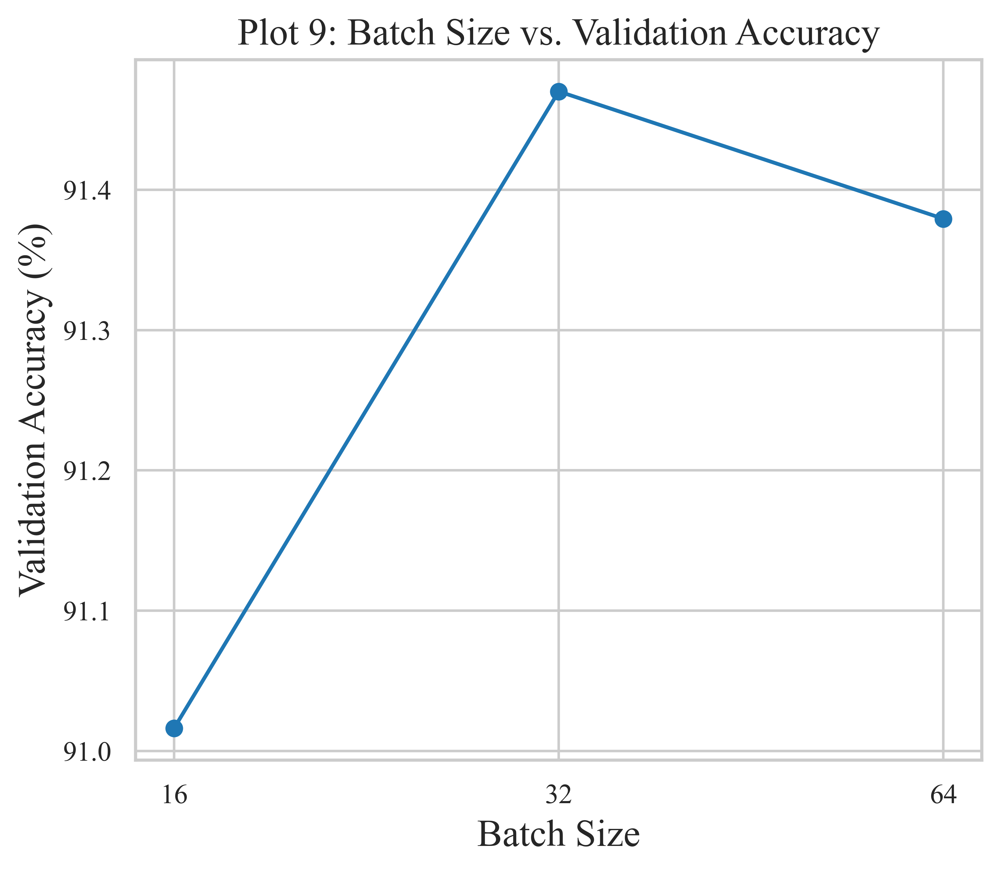

Saved: outputs/figures/plot10_dropout_vs_val_accuracy.eps


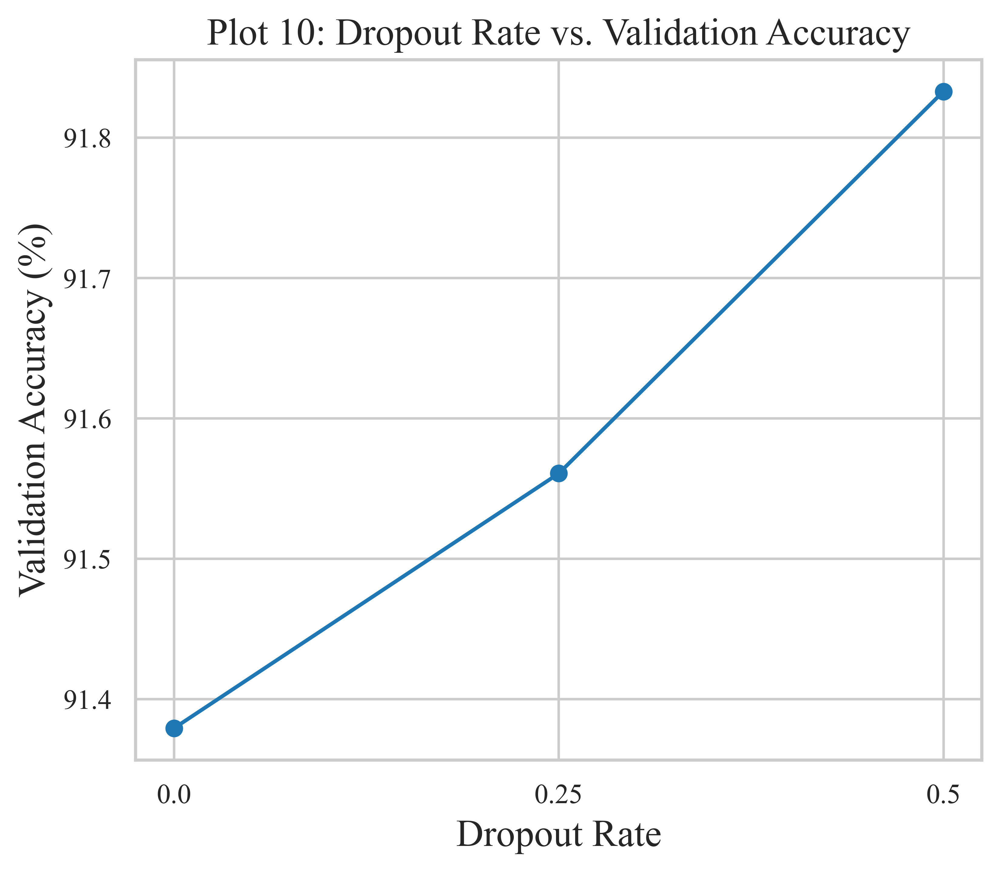


Example: N=224, K=3, P=1, S=1 -> O = 224
Example: N=224, K=3, P=0, S=2 -> O = 111


In [11]:

# Experimental rule: change ONE hyperparameter at a time, keep the rest fixed at these defaults.
DEFAULT_LR = 1e-3
DEFAULT_BATCH = 32
DEFAULT_DROPOUT = 0.25
EPOCHS_HP = 6

def train_and_get_best_val_acc(lr=DEFAULT_LR, batch_size=DEFAULT_BATCH, dropout_rate=DEFAULT_DROPOUT,
                                optimizer="adam", epochs=EPOCHS_HP):
    t_ds = make_dataset(train_df, batch_size=batch_size, shuffle=True, augment=True, cache=False)
    v_ds = make_dataset(val_df, batch_size=batch_size, cache=False)
    model, base = build_mobilenetv2_model(trainable_base=False, dropout_rate=dropout_rate, use_batchnorm=True)
    compile_model(model, optimizer, lr=lr)
    hist = model.fit(t_ds, validation_data=v_ds, epochs=epochs, verbose=0)
    best_acc = max(hist.history['val_accuracy'])
    history_dict = hist.history
    reset_keras(model, base, hist, t_ds, v_ds)
    return best_acc, history_dict

# --- Learning Rate sweep ---
lr_values = [0.001, 0.0001]
lr_results = {}
for lr in lr_values:
    print(f"Training LR={lr}")
    acc, _ = train_and_get_best_val_acc(lr=lr)
    lr_results[lr] = acc*100
    print(f"  Best Val Acc: {acc*100:.2f}%")

# --- Batch Size sweep ---
batch_values = [16, 32, 64]
batch_results = {}
for bs in batch_values:
    print(f"Training Batch Size={bs}")
    acc, _ = train_and_get_best_val_acc(batch_size=bs)
    batch_results[bs] = acc*100
    print(f"  Best Val Acc: {acc*100:.2f}%")

# --- Dropout Rate sweep ---
dropout_values = [0.0, 0.25, 0.5]
dropout_results = {}
for dr in dropout_values:
    print(f"Training Dropout={dr}")
    acc, _ = train_and_get_best_val_acc(dropout_rate=dr)
    dropout_results[dr] = acc*100
    print(f"  Best Val Acc: {acc*100:.2f}%")

hp_sweep_results = {"learning_rate": lr_results, "batch_size": batch_results, "dropout_rate": dropout_results}
with open("outputs/hp_sweep_results.json", "w") as f:
    json.dump(hp_sweep_results, f, indent=2, default=str)

# Plot 8: Learning Rate vs Validation Accuracy
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(list(map(str, lr_results.keys())), list(lr_results.values()), marker='o')
ax.set_xlabel("Learning Rate"); ax.set_ylabel("Validation Accuracy (%)"); ax.set_title("Plot 8: Learning Rate vs. Validation Accuracy")
style_axes(ax)
savefig(fig, "plot08_lr_vs_val_accuracy.eps")

# Plot 9: Batch Size vs Validation Accuracy
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(list(map(str, batch_results.keys())), list(batch_results.values()), marker='o')
ax.set_xlabel("Batch Size"); ax.set_ylabel("Validation Accuracy (%)"); ax.set_title("Plot 9: Batch Size vs. Validation Accuracy")
style_axes(ax)
savefig(fig, "plot09_batchsize_vs_val_accuracy.eps")

# Plot 10: Dropout Rate vs Validation Accuracy
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(list(map(str, dropout_results.keys())), list(dropout_results.values()), marker='o')
ax.set_xlabel("Dropout Rate"); ax.set_ylabel("Validation Accuracy (%)"); ax.set_title("Plot 10: Dropout Rate vs. Validation Accuracy")
style_axes(ax)
savefig(fig, "plot10_dropout_vs_val_accuracy.eps")

# Convolution output-dimension formula demo: O = floor((N + 2P - K)/S) + 1
def conv_output_dim(N, K, P, S):
    return (N + 2*P - K)//S + 1

print("\nExample: N=224, K=3, P=1, S=1 -> O =", conv_output_dim(224,3,1,1))
print("Example: N=224, K=3, P=0, S=2 -> O =", conv_output_dim(224,3,0,2))


## 6. Transfer Learning and Fine-Tuning

=== Case A: Feature Extraction ===
Epoch 1/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.6542 - loss: 1.2538 - val_accuracy: 0.8802 - val_loss: 0.3809
Epoch 2/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8499 - loss: 0.4716 - val_accuracy: 0.9038 - val_loss: 0.2938
Epoch 3/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8830 - loss: 0.3670 - val_accuracy: 0.9056 - val_loss: 0.2971
Epoch 4/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9055 - loss: 0.2950 - val_accuracy: 0.9056 - val_loss: 0.2884
Epoch 5/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9255 - loss: 0.2380 - val_accuracy: 0.9129 - val_loss: 0.2953
Epoch 6/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9298 - loss: 0.1985 - val_accuracy: 0.9174 - val_loss: 0.2835
Epoch 7/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9331 - loss: 0.1926 - val_accuracy: 0.9174 - val_loss: 0.2654
Epoch 8/8
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9

Saved: outputs/figures/plot11_feature_extraction_vs_finetuning.eps


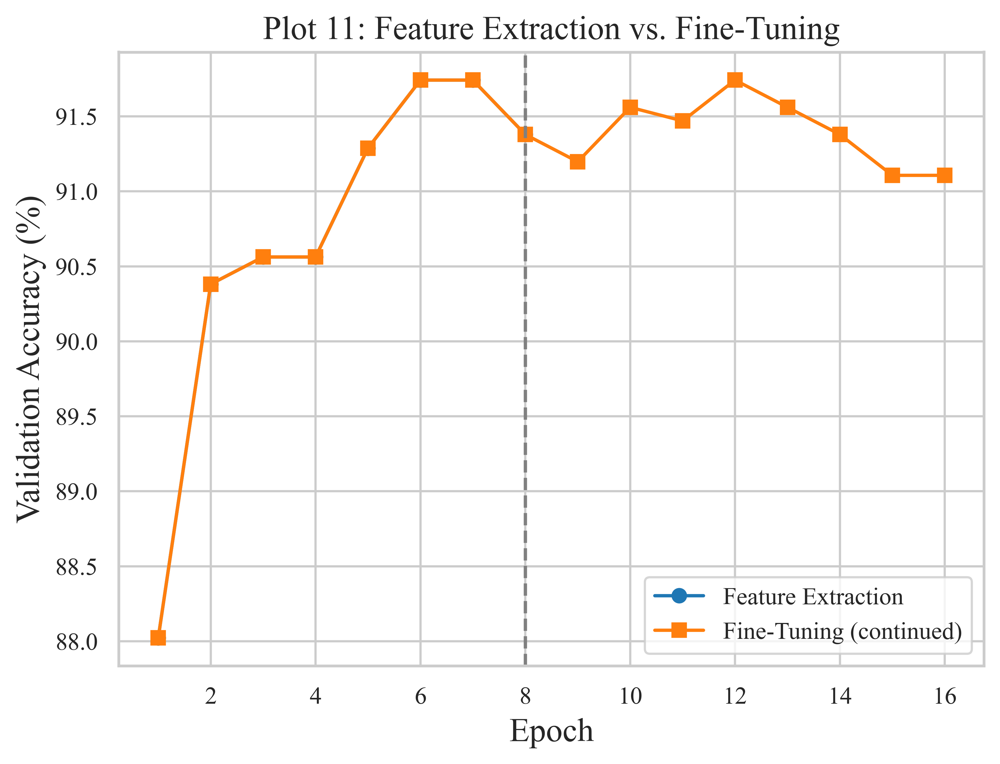

Saved: outputs/figures/plot12_loss_feature_extraction_vs_finetuning.eps


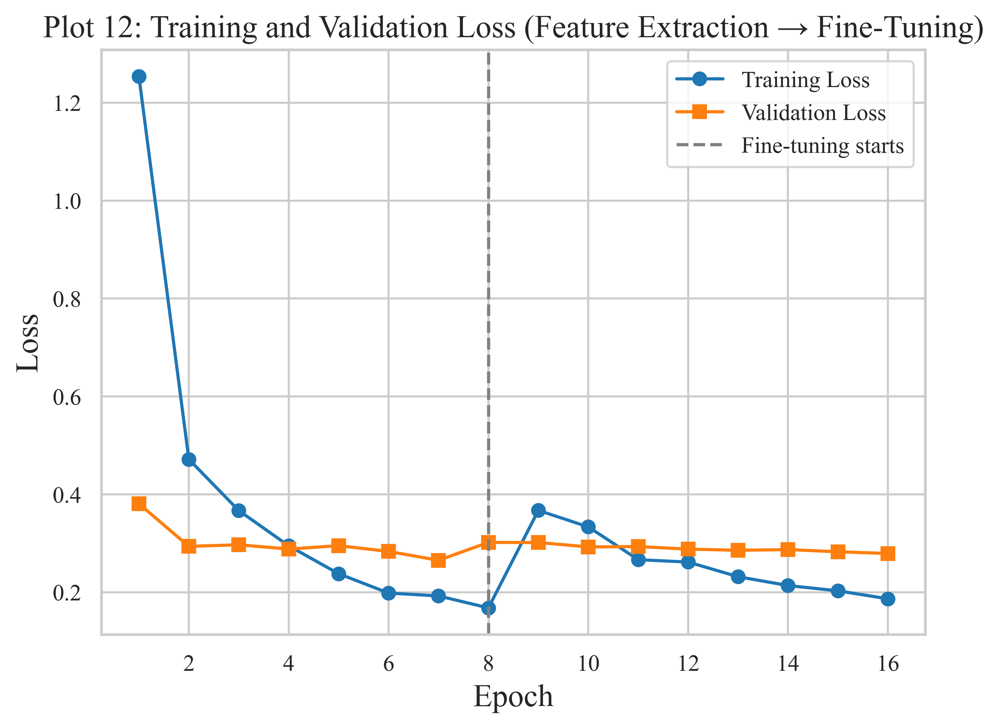

Cleared disk cache at /kaggle/working/cache


In [12]:

EPOCHS_FE = 8
EPOCHS_FT = 8

# Case A: Feature Extraction (frozen base)
print("=== Case A: Feature Extraction ===")
# Rebuild the disk cache for train_ds/val_ds since Section 5 cleared it after the optimizer/HP sweeps.
shutil.rmtree("/kaggle/working/cache", ignore_errors=True)
os.makedirs("/kaggle/working/cache", exist_ok=True)
train_ds = make_dataset(train_df, shuffle=True, augment=True, cache=True, cache_path="/kaggle/working/cache/train")
val_ds   = make_dataset(val_df, cache=True, cache_path="/kaggle/working/cache/val")

model_fe, base_fe = build_mobilenetv2_model(trainable_base=False, dropout_rate=0.5, use_batchnorm=True)
compile_model(model_fe, "adam", lr=1e-3)
hist_fe = model_fe.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FE, verbose=1)
hist_fe = hist_fe.history

# Case B: Fine-Tuning (unfreeze top layers of base, small LR), continuing from feature-extraction weights
print("\n=== Case B: Fine-Tuning ===")
base_fe.trainable = True
FINE_TUNE_AT = len(base_fe.layers) - 30  # unfreeze last 30 layers
for layer in base_fe.layers[:FINE_TUNE_AT]:
    layer.trainable = False

compile_model(model_fe, "adam", lr=1e-5)  # smaller LR for fine-tuning
hist_ft = model_fe.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FT, verbose=1)
hist_ft = hist_ft.history

# Combine FE + FT histories for a continuous fine-tuning curve
combined_val_acc = hist_fe['val_accuracy'] + hist_ft['val_accuracy']
combined_train_loss = hist_fe['loss'] + hist_ft['loss']
combined_val_loss = hist_fe['val_loss'] + hist_ft['val_loss']

reset_keras(model_fe, base_fe)

# Plot 11: Feature Extraction vs Fine-Tuning (Validation Accuracy)
fig, ax = plt.subplots(figsize=(7,5))
ep_fe = range(1, EPOCHS_FE+1)
ax.plot(ep_fe, [v*100 for v in hist_fe['val_accuracy']], marker='o', label='Feature Extraction')
ep_full = range(1, EPOCHS_FE+EPOCHS_FT+1)
ax.plot(ep_full, [v*100 for v in combined_val_acc], marker='s', label='Fine-Tuning (continued)')
ax.axvline(x=EPOCHS_FE, linestyle='--', color='gray')
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)"); ax.set_title("Plot 11: Feature Extraction vs. Fine-Tuning")
ax.legend()
style_axes(ax)
savefig(fig, "plot11_feature_extraction_vs_finetuning.eps")

# Plot 12: Training and Validation Loss (before vs after fine-tuning)
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(ep_full, combined_train_loss, marker='o', label='Training Loss')
ax.plot(ep_full, combined_val_loss, marker='s', label='Validation Loss')
ax.axvline(x=EPOCHS_FE, linestyle='--', color='gray', label='Fine-tuning starts')
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title("Plot 12: Training and Validation Loss (Feature Extraction \u2192 Fine-Tuning)")
ax.legend()
style_axes(ax)
savefig(fig, "plot12_loss_feature_extraction_vs_finetuning.eps")

# Section 6 is done with train_ds/val_ds; K-Fold CV (Section 7) builds its own uncached per-fold
# datasets, so this cache is no longer needed until Section 8's final retrain.
clear_disk_cache()


## 7. K-Fold Cross-Validation


########## Configuration: C1_Baseline_Adam_Dropout0.5 ##########
 Fold 1/5
   Fold 1 Best Val Acc: 91.06%
 Fold 2/5
   Fold 2 Best Val Acc: 91.35%
 Fold 3/5
   Fold 3 Best Val Acc: 91.35%
 Fold 4/5
   Fold 4 Best Val Acc: 91.45%
 Fold 5/5
   Fold 5 Best Val Acc: 90.95%

########## Configuration: C2_Adam_LowLR_Dropout0.25 ##########
 Fold 1/5
   Fold 1 Best Val Acc: 88.14%
 Fold 2/5
   Fold 2 Best Val Acc: 87.56%
 Fold 3/5
   Fold 3 Best Val Acc: 88.82%
 Fold 4/5
   Fold 4 Best Val Acc: 87.46%
 Fold 5/5
   Fold 5 Best Val Acc: 89.59%

########## Configuration: C3_RMSProp_Dropout0.5_BN ##########
 Fold 1/5
   Fold 1 Best Val Acc: 91.06%
 Fold 2/5
   Fold 2 Best Val Acc: 91.64%
 Fold 3/5
   Fold 3 Best Val Acc: 91.74%
 Fold 4/5
   Fold 4 Best Val Acc: 91.55%
 Fold 5/5
   Fold 5 Best Val Acc: 91.63%

########## Configuration: C4_Adam_L2Reg ##########
 Fold 1/5
   Fold 1 Best Val Acc: 90.77%
 Fold 2/5
   Fold 2 Best Val Acc: 90.96%
 Fold 3/5
   Fold 3 Best Val Acc: 91.74%
 Fold 4/5
   Fold

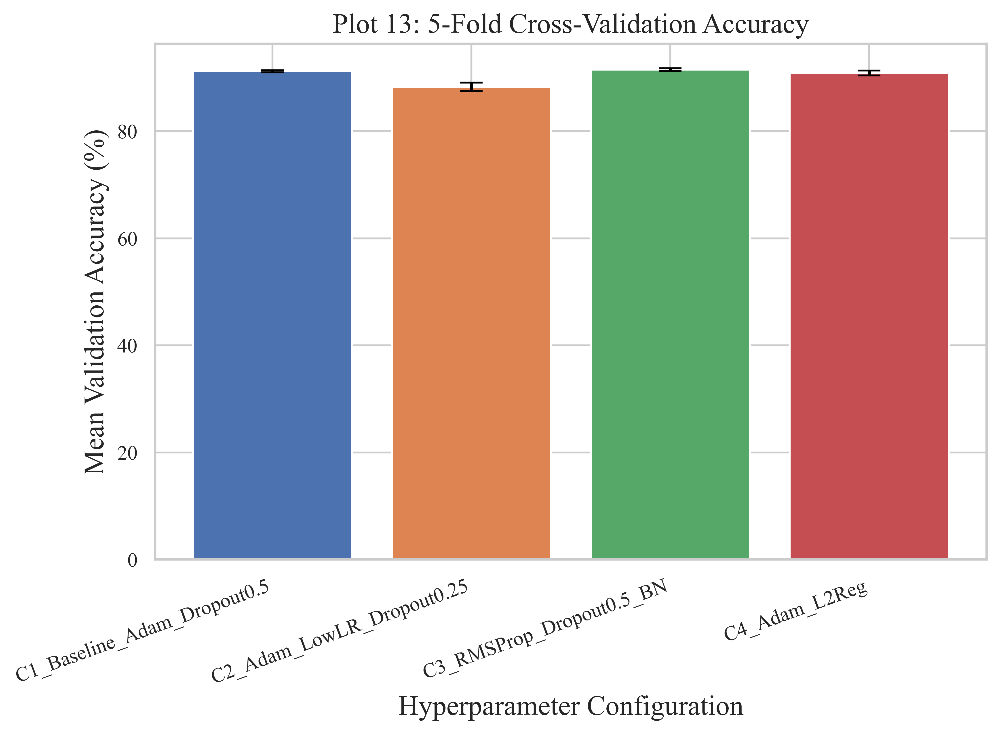

Best configuration selected via CV: C3_RMSProp_Dropout0.5_BN


In [13]:

# Select 3-4 promising configurations based on prior sections' results, then run 5-fold CV on the TRAINING data only.
K = 5
EPOCHS_CV = 5

configurations = {
    "C1_Baseline_Adam_Dropout0.5": dict(optimizer="adam", lr=1e-3, dropout_rate=0.5, use_batchnorm=True, l2_reg=0.0),
    "C2_Adam_LowLR_Dropout0.25":   dict(optimizer="adam", lr=1e-4, dropout_rate=0.25, use_batchnorm=True, l2_reg=0.0),
    "C3_RMSProp_Dropout0.5_BN":    dict(optimizer="rmsprop", lr=1e-3, dropout_rate=0.5, use_batchnorm=True, l2_reg=0.0),
    "C4_Adam_L2Reg":               dict(optimizer="adam", lr=1e-3, dropout_rate=0.0, use_batchnorm=True, l2_reg=1e-3),
}

kf = KFold(n_splits=K, shuffle=True, random_state=SEED)
train_indices = train_df.reset_index(drop=True)

cv_results = {name: [] for name in configurations}

for cfg_name, cfg in configurations.items():
    print(f"\n########## Configuration: {cfg_name} ##########")
    fold_accs = []
    for fold_i, (tr_idx, va_idx) in enumerate(kf.split(train_indices), start=1):
        print(f" Fold {fold_i}/{K}")
        fold_train_df = train_indices.iloc[tr_idx]
        fold_val_df = train_indices.iloc[va_idx]

        fold_train_ds = make_dataset(fold_train_df, shuffle=True, augment=True, cache=False)
        fold_val_ds = make_dataset(fold_val_df, cache=False)

        model, base = build_mobilenetv2_model(trainable_base=False,
                                               dropout_rate=cfg["dropout_rate"],
                                               use_batchnorm=cfg["use_batchnorm"],
                                               l2_reg=cfg["l2_reg"])
        compile_model(model, cfg["optimizer"], lr=cfg["lr"])
        hist = model.fit(fold_train_ds, validation_data=fold_val_ds, epochs=EPOCHS_CV, verbose=0)
        fold_best_acc = max(hist.history['val_accuracy'])
        fold_accs.append(fold_best_acc)
        print(f"   Fold {fold_i} Best Val Acc: {fold_best_acc*100:.2f}%")
        reset_keras(model, base, hist, fold_train_ds, fold_val_ds)
    cv_results[cfg_name] = fold_accs

# Build results table
cv_table_rows = []
for cfg_name, accs in cv_results.items():
    accs_pct = [a*100 for a in accs]
    row = {"Configuration": cfg_name}
    for i, a in enumerate(accs_pct, start=1):
        row[f"F{i}"] = round(a, 2)
    row["Mean"] = round(np.mean(accs_pct), 2)
    row["SD"] = round(np.std(accs_pct), 2)
    cv_table_rows.append(row)

cv_table = pd.DataFrame(cv_table_rows)
cv_table.to_csv("outputs/cv_results.csv", index=False)
print(cv_table)

# Plot 13: 5-Fold Cross-Validation Accuracy with SD error bars
fig, ax = plt.subplots(figsize=(8,5))
means = cv_table["Mean"].values
sds = cv_table["SD"].values
names = cv_table["Configuration"].values
x_pos = np.arange(len(names))
ax.bar(x_pos, means, yerr=sds, capsize=6, color=['#4C72B0','#DD8452','#55A868','#C44E52'][:len(names)])
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_xlabel("Hyperparameter Configuration"); ax.set_ylabel("Mean Validation Accuracy (%)")
ax.set_title("Plot 13: 5-Fold Cross-Validation Accuracy")
style_axes(ax)
savefig(fig, "plot13_5fold_cv_accuracy.eps")

# Identify best configuration by mean accuracy (tie-break: lower SD)
best_cfg_name = cv_table.sort_values(by=["Mean","SD"], ascending=[False, True]).iloc[0]["Configuration"]
print("Best configuration selected via CV:", best_cfg_name)


## 8. Final Model Evaluation

In [14]:

EPOCHS_FINAL = 12

# Rebuild the disk cache for train_ds/val_ds/test_ds (cleared after Section 6; Section 7's K-Fold
# loops intentionally did not use it).
shutil.rmtree("/kaggle/working/cache", ignore_errors=True)
os.makedirs("/kaggle/working/cache", exist_ok=True)
train_ds = make_dataset(train_df, shuffle=True, augment=True, cache=True, cache_path="/kaggle/working/cache/train")
val_ds   = make_dataset(val_df, cache=True, cache_path="/kaggle/working/cache/val")
test_ds  = make_dataset(test_df, cache=True, cache_path="/kaggle/working/cache/test")

best_cfg = configurations[best_cfg_name]
print("Retraining best configuration on FULL training data:", best_cfg_name, best_cfg)

final_model, final_base = build_mobilenetv2_model(trainable_base=False,
                                                    dropout_rate=best_cfg["dropout_rate"],
                                                    use_batchnorm=best_cfg["use_batchnorm"],
                                                    l2_reg=best_cfg["l2_reg"])
compile_model(final_model, best_cfg["optimizer"], lr=best_cfg["lr"])

t0 = time.time()
final_hist = final_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINAL, verbose=1)
training_time = time.time() - t0

num_params = final_model.count_params()

# Evaluate on the untouched TEST set
y_true, y_pred = [], []
for batch_x, batch_y in test_ds:
    preds = final_model.predict(batch_x, verbose=0)
    y_true.extend(np.argmax(batch_y.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true); y_pred = np.array(y_pred)

test_accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

cv_row = cv_table[cv_table["Configuration"] == best_cfg_name].iloc[0]

final_report = {
    "Mean CV Accuracy (%)": cv_row["Mean"],
    "CV Standard Deviation": cv_row["SD"],
    "Test Accuracy (%)": round(test_accuracy*100, 2),
    "Precision (macro)": round(precision, 4),
    "Recall (macro)": round(recall, 4),
    "F1-score (macro)": round(f1, 4),
    "Training Time (s)": round(training_time, 1),
    "Number of Parameters": num_params
}
final_report_df = pd.DataFrame(list(final_report.items()), columns=["Metric", "Value"])
final_report_df.to_csv("outputs/final_model_report.csv", index=False)
print(final_report_df)

final_model.save("outputs/final_model.keras")


Retraining best configuration on FULL training data: C3_RMSProp_Dropout0.5_BN {'optimizer': 'rmsprop', 'lr': 0.001, 'dropout_rate': 0.5, 'use_batchnorm': True, 'l2_reg': 0.0}
Epoch 1/12
161/161 ━━━━━━━━━━━━━━━━━━━━ 27s 112ms/step - accuracy: 0.6862 - loss: 1.1493 - val_accuracy: 0.8920 - val_loss: 0.3488
Epoch 2/12
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.8565 - loss: 0.4759 - val_accuracy: 0.9102 - val_loss: 0.3025
Epoch 3/12
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8892 - loss: 0.3691 - val_accuracy: 0.9129 - val_loss: 0.3043
Epoch 4/12
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9030 - loss: 0.3187 - val_accuracy: 0.9065 - val_loss: 0.3183
Epoch 5/12
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9166 - loss: 0.2613 - val_accuracy: 0.9238 - val_loss: 0.3049
Epoch 6/12
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9277 - loss: 0.2355 - val_accuracy: 0.9083 - val_loss: 0.3011
Epoch 7/12
161/161 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/s

In [15]:

# Plot 14: Confusion Matrix (final model, test set)
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(16,14))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(np.arange(NUM_CLASSES)); ax.set_yticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6)
ax.set_yticklabels(CLASS_NAMES, fontsize=6)
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
ax.set_title("Plot 14: Confusion Matrix (Final Model on Test Set)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
style_axes(ax)
savefig(fig, "plot14_confusion_matrix.png", fmt="png")

# Identify best-classified and most-confused class pairs
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
best_classes_idx = np.argsort(per_class_acc)[::-1][:5]
print("Top-5 best classified classes:")
for idx in best_classes_idx:
    print(f"  {CLASS_NAMES[idx]}: {per_class_acc[idx]*100:.1f}%")

cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
confused_pairs = []
flat_idx = np.dstack(np.unravel_index(np.argsort(cm_offdiag.ravel())[::-1][:5], cm_offdiag.shape))[0]
for i, j in flat_idx:
    if cm_offdiag[i, j] > 0:
        confused_pairs.append((CLASS_NAMES[i], CLASS_NAMES[j], int(cm_offdiag[i, j])))
print("\nTop confused class pairs (true -> predicted, count):")
for pair in confused_pairs:
    print(f"  {pair[0]} -> {pair[1]}: {pair[2]}")


Saved: outputs/figures/plot14_confusion_matrix.png
Saved: outputs/figures/plot14_confusion_matrix.pdf


Top-5 best classified classes:
  yorkshire_terrier: 100.0%
  Siamese: 100.0%
  Sphynx: 100.0%
  great_pyrenees: 100.0%
  leonberger: 100.0%

Top confused class pairs (true -> predicted, count):
  Russian_Blue -> British_Shorthair: 7
  american_pit_bull_terrier -> staffordshire_bull_terrier: 6
  British_Shorthair -> Russian_Blue: 6
  staffordshire_bull_terrier -> american_bulldog: 4
  Ragdoll -> Birman: 4


Saved: outputs/figures/plot15_misclassified_images.png
Saved: outputs/figures/plot15_misclassified_images.pdf


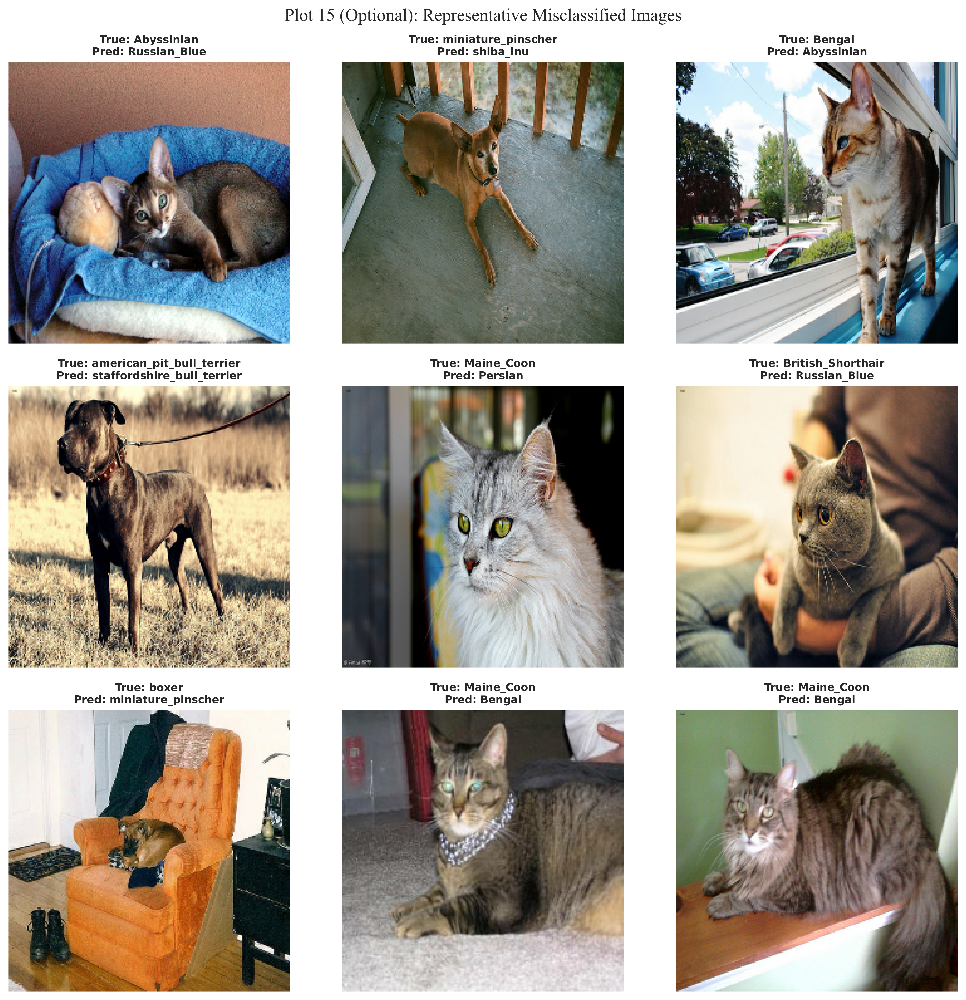

In [16]:

# Optional Plot 15: Misclassified Images (representative samples)
misclassified_idx = np.where(y_true != y_pred)[0]
n_show = min(9, len(misclassified_idx))
sample_idx = np.random.choice(misclassified_idx, size=n_show, replace=False) if n_show > 0 else []

test_idxs = test_df['idx'].values  # positional order matches y_true/y_pred (test_ds built with shuffle=False)

fig, axes = plt.subplots(3, 3, figsize=(12,12))
for ax, idx in zip(axes.flat, sample_idx):
    img = ALL_IMAGES[test_idxs[idx]]  # already 224x224x3 uint8, no decode/resize needed
    ax.imshow(img)
    ax.set_title(f"True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}", fontsize=9)
    ax.axis('off')
for ax in axes.flat[len(sample_idx):]:
    ax.axis('off')
fig.suptitle("Plot 15 (Optional): Representative Misclassified Images", fontweight='bold', fontsize=15, fontname=FONT_NAME)
fig.tight_layout()
savefig(fig, "plot15_misclassified_images.png", fmt="png")


## 9. Overall Results Summary

In [17]:

# Consolidate results from every stage into the manual's "Overall Results" table.
baseline_val_acc = max(reg_histories["No Regularization"]['val_accuracy']) * 100
best_init_name = max(init_histories, key=lambda k: max(init_histories[k]['val_accuracy']))
best_init_acc = max(init_histories[best_init_name]['val_accuracy']) * 100
best_reg_name = max(reg_histories, key=lambda k: max(reg_histories[k]['val_accuracy']))
best_reg_acc = max(reg_histories[best_reg_name]['val_accuracy']) * 100
best_opt_row = optimizer_summary_df.sort_values("Best Val. Accuracy", ascending=False).iloc[0]
best_hp_acc = max(list(lr_results.values()) + list(batch_results.values()) + list(dropout_results.values()))
finetuned_acc = max(combined_val_acc) * 100

overall_results = pd.DataFrame([
    {"Configuration": "Baseline (No Regularization)", "CV Accuracy": "-", "SD": "-",
     "Test Accuracy": f"{baseline_val_acc:.2f}% (val)", "Training Time": "-"},
    {"Configuration": f"Best Initialization ({best_init_name})", "CV Accuracy": "-", "SD": "-",
     "Test Accuracy": f"{best_init_acc:.2f}% (val)", "Training Time": "-"},
    {"Configuration": f"Best Regularization ({best_reg_name})", "CV Accuracy": "-", "SD": "-",
     "Test Accuracy": f"{best_reg_acc:.2f}% (val)", "Training Time": "-"},
    {"Configuration": f"Best Optimizer ({best_opt_row['Optimizer']})", "CV Accuracy": "-", "SD": "-",
     "Test Accuracy": f"{best_opt_row['Best Val. Accuracy']:.2f}% (val)", "Training Time": f"{best_opt_row['Time (s)']}s"},
    {"Configuration": "Best Hyperparameters (from sweeps)", "CV Accuracy": "-", "SD": "-",
     "Test Accuracy": f"{best_hp_acc:.2f}% (val)", "Training Time": "-"},
    {"Configuration": "Fine-Tuned Model", "CV Accuracy": "-", "SD": "-",
     "Test Accuracy": f"{finetuned_acc:.2f}% (val)", "Training Time": "-"},
    {"Configuration": f"Final Selected Model ({best_cfg_name})",
     "CV Accuracy": f"{final_report['Mean CV Accuracy (%)']}%",
     "SD": final_report['CV Standard Deviation'],
     "Test Accuracy": f"{final_report['Test Accuracy (%)']}%",
     "Training Time": f"{final_report['Training Time (s)']}s"},
])
overall_results.to_csv("outputs/overall_results_summary.csv", index=False)
overall_results


,Configuration,CV Accuracy,SD,Test Accuracy,Training Time
0,Baseline (No Regularization),-,-,91.56% (val),-
1,Best Initialization (He),-,-,92.11% (val),-
2,Best Regularization (Dropout),-,-,92.01% (val),-
3,Best Optimizer (RMSProp),-,-,92.38% (val),74.7s
4,Best Hyperparameters (from sweeps),-,-,92.47% (val),-
5,Fine-Tuned Model,-,-,91.74% (val),-
6,Final Selected Model (C3_RMSProp_Dropout0.5_BN),91.52%,0.24,90.03%,87.1s


## 10. Additional Exercise: New Configurations via 5-Fold Cross-Validation

In [18]:

# Section 8/9 are done with train_ds/val_ds/test_ds; free that disk cache before this section's
# 10 fold trainings (2 configs x 5 folds), which build their own uncached per-fold datasets anyway.
clear_disk_cache()

# Select TWO new combinations of learning rate, dropout, batch size and fine-tuning strategy,
# evaluate with 5-fold CV, and compare against the previously selected best configuration.
EPOCHS_ADD_CV = 5

new_configurations = {
    "N1_LowLR_HighDropout_SmallBatch_FT": dict(optimizer="adam", lr=1e-4, dropout_rate=0.5,
                                                use_batchnorm=True, l2_reg=0.0, batch_size=16, fine_tune=True),
    "N2_HighLR_LowDropout_LargeBatch_FE": dict(optimizer="adam", lr=1e-3, dropout_rate=0.1,
                                                use_batchnorm=True, l2_reg=0.0, batch_size=64, fine_tune=False),
}

new_cv_results = {}
for cfg_name, cfg in new_configurations.items():
    print(f"\n########## New Configuration: {cfg_name} ##########")
    fold_accs = []
    for fold_i, (tr_idx, va_idx) in enumerate(kf.split(train_indices), start=1):
        print(f" Fold {fold_i}/{K}")
        fold_train_df = train_indices.iloc[tr_idx]
        fold_val_df = train_indices.iloc[va_idx]
        fold_train_ds = make_dataset(fold_train_df, batch_size=cfg["batch_size"], shuffle=True, augment=True, cache=False)
        fold_val_ds = make_dataset(fold_val_df, batch_size=cfg["batch_size"], cache=False)

        model, base = build_mobilenetv2_model(trainable_base=False,
                                               dropout_rate=cfg["dropout_rate"],
                                               use_batchnorm=cfg["use_batchnorm"],
                                               l2_reg=cfg["l2_reg"])
        compile_model(model, cfg["optimizer"], lr=cfg["lr"])
        model.fit(fold_train_ds, validation_data=fold_val_ds, epochs=EPOCHS_ADD_CV, verbose=0)

        if cfg["fine_tune"]:
            base.trainable = True
            for layer in base.layers[:len(base.layers)-20]:
                layer.trainable = False
            compile_model(model, cfg["optimizer"], lr=cfg["lr"]/10)
            model.fit(fold_train_ds, validation_data=fold_val_ds, epochs=3, verbose=0)

        val_eval = model.evaluate(fold_val_ds, verbose=0)
        fold_accs.append(val_eval[1])
        print(f"   Fold {fold_i} Val Acc: {val_eval[1]*100:.2f}%")
        reset_keras(model, base, fold_train_ds, fold_val_ds)
    new_cv_results[cfg_name] = fold_accs

new_cv_rows = []
for cfg_name, accs in new_cv_results.items():
    accs_pct = [a*100 for a in accs]
    row = {"Configuration": cfg_name}
    for i, a in enumerate(accs_pct, start=1):
        row[f"F{i}"] = round(a, 2)
    row["Mean"] = round(np.mean(accs_pct), 2)
    row["SD"] = round(np.std(accs_pct), 2)
    new_cv_rows.append(row)

# Append previously selected best configuration for direct comparison
prev_best_row = cv_table[cv_table["Configuration"] == best_cfg_name].to_dict(orient="records")[0]
new_cv_rows.append(prev_best_row)

comparison_table = pd.DataFrame(new_cv_rows)
comparison_table.to_csv("outputs/additional_exercise_comparison.csv", index=False)
print(comparison_table)


Cleared disk cache at /kaggle/working/cache

########## New Configuration: N1_LowLR_HighDropout_SmallBatch_FT ##########
 Fold 1/5
   Fold 1 Val Acc: 89.60%
 Fold 2/5
   Fold 2 Val Acc: 90.96%
 Fold 3/5
   Fold 3 Val Acc: 89.70%
 Fold 4/5
   Fold 4 Val Acc: 87.95%
 Fold 5/5
   Fold 5 Val Acc: 89.40%

########## New Configuration: N2_HighLR_LowDropout_LargeBatch_FE ##########
 Fold 1/5
   Fold 1 Val Acc: 89.70%
 Fold 2/5
   Fold 2 Val Acc: 91.45%
 Fold 3/5
   Fold 3 Val Acc: 91.55%
 Fold 4/5
   Fold 4 Val Acc: 89.50%
 Fold 5/5
   Fold 5 Val Acc: 90.76%
                        Configuration     F1     F2     F3     F4     F5  \
0  N1_LowLR_HighDropout_SmallBatch_FT  89.60  90.96  89.70  87.95  89.40   
1  N2_HighLR_LowDropout_LargeBatch_FE  89.70  91.45  91.55  89.50  90.76   
2            C3_RMSProp_Dropout0.5_BN  91.06  91.64  91.74  91.55  91.63   

    Mean    SD  
0  89.52  0.96  
1  90.59  0.85  
2  91.52  0.24  


## 11. Export Figures

In [19]:
# ---- Zip all EPS figures and provide a download link ----
import glob
import zipfile

eps_files = sorted(glob.glob(os.path.join(FIG_DIR, "*.eps")))
print(f"Found {len(eps_files)} EPS files:")
for eps_file in eps_files:
    print(" -", eps_file)

EPS_ZIP_PATH = "outputs/lab5_eps_plots.zip"
with zipfile.ZipFile(EPS_ZIP_PATH, "w") as zip_file:
    for eps_file in eps_files:
        zip_file.write(eps_file, arcname=os.path.basename(eps_file))

print("\nZIP archive created:", EPS_ZIP_PATH)

try:
    from google.colab import files
    files.download(EPS_ZIP_PATH)
except ImportError:
    try:
        from IPython.display import FileLink, display
        display(FileLink(EPS_ZIP_PATH))
    except Exception:
        pass
    print("Not running in Google Colab -- the ZIP file is saved at", EPS_ZIP_PATH,
          "(on Kaggle, download it from the 'Output' tab of the notebook's right-hand panel).")


Found 13 EPS files:
 - outputs/figures/plot01_training_loss_vs_epoch_initialization.eps
 - outputs/figures/plot02_val_accuracy_vs_epoch_initialization.eps
 - outputs/figures/plot03_train_val_accuracy_vs_epoch_regularization.eps
 - outputs/figures/plot04_train_val_loss_vs_epoch_regularization.eps
 - outputs/figures/plot05_with_vs_without_bn.eps
 - outputs/figures/plot06_training_loss_vs_epoch_optimizers.eps
 - outputs/figures/plot07_val_accuracy_vs_epoch_optimizers.eps
 - outputs/figures/plot08_lr_vs_val_accuracy.eps
 - outputs/figures/plot09_batchsize_vs_val_accuracy.eps
 - outputs/figures/plot10_dropout_vs_val_accuracy.eps
 - outputs/figures/plot11_feature_extraction_vs_finetuning.eps
 - outputs/figures/plot12_loss_feature_extraction_vs_finetuning.eps
 - outputs/figures/plot13_5fold_cv_accuracy.eps

ZIP archive created: outputs/lab5_eps_plots.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# ---- Convert every EPS figure to PDF (Ghostscript) and zip the PDFs for download ----
import subprocess

PDF_DIR = "outputs/figures_pdf"
os.makedirs(PDF_DIR, exist_ok=True)

def eps_to_pdf(eps_path, pdf_path):
    """Convert a single EPS file to PDF using Ghostscript (same tool used earlier in this course
    to make EPS figures embeddable in the LaTeX/Overleaf report)."""
    result = subprocess.run(
        ["gs", "-dBATCH", "-dNOPAUSE", "-dEPSCrop", "-dSAFER",
         "-sDEVICE=pdfwrite", f"-sOutputFile={pdf_path}", eps_path],
        capture_output=True, text=True
    )
    return result.returncode == 0, result.stderr

# Make sure Ghostscript is available (installs it if this environment doesn't already have it).
if subprocess.run(["which", "gs"], capture_output=True).returncode != 0:
    os.system("apt-get -qq install -y ghostscript > /dev/null 2>&1")

pdf_files = []
for eps_path in eps_files:
    pdf_path = os.path.join(PDF_DIR, os.path.splitext(os.path.basename(eps_path))[0] + ".pdf")
    ok, err = eps_to_pdf(eps_path, pdf_path)
    if ok:
        print("Converted:", eps_path, "->", pdf_path)
        pdf_files.append(pdf_path)
    else:
        print("FAILED to convert:", eps_path)
        print(err[:300])

# Plots that were saved as PNG (raster content: confusion matrix, misclassified images) already
# have a direct PDF saved alongside them in FIG_DIR (see savefig()) -- copy those in too, so every
# plot ends up in the PDF zip, not just the ones that went through Ghostscript.
import shutil as _shutil
direct_pdfs = sorted(glob.glob(os.path.join(FIG_DIR, "*.pdf")))
for src_pdf in direct_pdfs:
    dst_pdf = os.path.join(PDF_DIR, os.path.basename(src_pdf))
    _shutil.copy(src_pdf, dst_pdf)
    print("Copied direct PDF:", src_pdf, "->", dst_pdf)
    pdf_files.append(dst_pdf)

PDF_ZIP_PATH = "outputs/lab5_pdf_plots.zip"
with zipfile.ZipFile(PDF_ZIP_PATH, "w") as zip_file:
    for pdf_file in pdf_files:
        zip_file.write(pdf_file, arcname=os.path.basename(pdf_file))

print(f"\nConverted {len(pdf_files)}/{len(eps_files)} figures to PDF.")
print("ZIP archive created:", PDF_ZIP_PATH)

try:
    from google.colab import files
    files.download(PDF_ZIP_PATH)
except ImportError:
    try:
        from IPython.display import FileLink, display
        display(FileLink(PDF_ZIP_PATH))
    except Exception:
        pass
    print("Not running in Google Colab -- the ZIP file is saved at", PDF_ZIP_PATH,
          "(on Kaggle, download it from the 'Output' tab of the notebook's right-hand panel).")


Converted: outputs/figures/plot01_training_loss_vs_epoch_initialization.eps -> outputs/figures_pdf/plot01_training_loss_vs_epoch_initialization.pdf
Converted: outputs/figures/plot02_val_accuracy_vs_epoch_initialization.eps -> outputs/figures_pdf/plot02_val_accuracy_vs_epoch_initialization.pdf
Converted: outputs/figures/plot03_train_val_accuracy_vs_epoch_regularization.eps -> outputs/figures_pdf/plot03_train_val_accuracy_vs_epoch_regularization.pdf
Converted: outputs/figures/plot04_train_val_loss_vs_epoch_regularization.eps -> outputs/figures_pdf/plot04_train_val_loss_vs_epoch_regularization.pdf
Converted: outputs/figures/plot05_with_vs_without_bn.eps -> outputs/figures_pdf/plot05_with_vs_without_bn.pdf
Converted: outputs/figures/plot06_training_loss_vs_epoch_optimizers.eps -> outputs/figures_pdf/plot06_training_loss_vs_epoch_optimizers.pdf
Converted: outputs/figures/plot07_val_accuracy_vs_epoch_optimizers.eps -> outputs/figures_pdf/plot07_val_accuracy_vs_epoch_optimizers.pdf
Converted:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>